# Crop Recommendation Retraining v2

Notebook này train lại mô hình từ đầu theo quy trình nghiên cứu khoa học và triển khai production.

## Mục tiêu
- Tiền xử lý dữ liệu trước train: xử lý null/NaN, loại trùng, xử lý ngoại lai.
- Trực quan hóa dữ liệu đa dạng trước và sau khi train.
- Huấn luyện và so sánh 4 mô hình: Random Forest, Naive Bayes, KNN, SVM.
- Theo dõi history nhiều chỉ số để đánh giá hiệu năng và độ ổn định.
- Chọn mô hình tốt nhất theo cả độ chính xác và độ ổn định.
- Lưu artifact phiên bản mới (model + scaler + log metrics) để deploy vào predict server.

## Cấu trúc quy trình
1. Thiết lập môi trường và import thư viện.
2. Khai báo cấu hình tập trung.
3. Nạp dữ liệu và kiểm tra chất lượng.
4. Tiền xử lý và trực quan hóa trước train.
5. Cài đặt hàm lõi cho pipeline.
6. Chạy train end-to-end và lưu history.
7. Đánh giá kết quả bằng nhiều metrics và biểu đồ.
8. Lưu artifact phiên bản mới và smoke test mô hình đã lưu.

In [14]:
# 1) Thiết lập môi trường và import thư viện
import os
import pickle
import json
import time
import warnings
from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

# Scientific plotting style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10

print("Environment ready")
print(f"numpy={np.__version__}")
print(f"pandas={pd.__version__}")
print(f"seaborn={sns.__version__}")

Environment ready
numpy=2.3.3
pandas=2.3.3
seaborn=0.13.2


## 2) Khai báo cấu hình và tham số chạy

Toàn bộ tham số được gom vào một cấu hình trung tâm để dễ tái lập và thay đổi.

Lưu ý tương thích production hiện tại:
- Thứ tự scaler phải là **MinMaxScaler -> StandardScaler**.
- Mục tiêu (label) được map về ID cố định 1..22 để khớp với predict server.

In [2]:
@dataclass
class TrainConfig:
    random_seed: int = 42
    test_size: float = 0.2
    cv_folds: int = 5
    dataset_path: str = "./Crop_recommendation.csv"
    model_root: str = "./models"
    output_root: str = "./training_outputs"

    rf_params: dict = None
    knn_params: dict = None
    svm_params: dict = None

    def __post_init__(self):
        if self.rf_params is None:
            self.rf_params = {
                "n_estimators": 400,
                "max_depth": None,
                "min_samples_split": 2,
                "min_samples_leaf": 1,
                "random_state": self.random_seed,
                "n_jobs": -1,
            }
        if self.knn_params is None:
            self.knn_params = {
                "n_neighbors": 9,
                "weights": "distance",
                "metric": "minkowski",
            }
        if self.svm_params is None:
            self.svm_params = {
                "kernel": "rbf",
                "C": 10,
                "gamma": "scale",
                "probability": True,
                "random_state": self.random_seed,
            }


CONFIG = TrainConfig()
np.random.seed(CONFIG.random_seed)

CROP_TO_ID = {
    "rice": 1, "maize": 2, "jute": 3, "cotton": 4, "coconut": 5,
    "papaya": 6, "orange": 7, "apple": 8, "muskmelon": 9, "watermelon": 10,
    "grapes": 11, "mango": 12, "banana": 13, "pomegranate": 14, "lentil": 15,
    "blackgram": 16, "mungbean": 17, "mothbeans": 18, "pigeonpeas": 19,
    "kidneybeans": 20, "chickpea": 21, "coffee": 22,
}
ID_TO_CROP = {v: k for k, v in CROP_TO_ID.items()}

FEATURE_COLUMNS = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
TARGET_COLUMN = "label"

print("CONFIG:")
print(json.dumps(asdict(CONFIG), indent=2, ensure_ascii=False))

CONFIG:
{
  "random_seed": 42,
  "test_size": 0.2,
  "cv_folds": 5,
  "dataset_path": "./Crop_recommendation.csv",
  "model_root": "./models",
  "output_root": "./training_outputs",
  "rf_params": {
    "n_estimators": 400,
    "max_depth": null,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "random_state": 42,
    "n_jobs": -1
  },
  "knn_params": {
    "n_neighbors": 9,
    "weights": "distance",
    "metric": "minkowski"
  },
  "svm_params": {
    "kernel": "rbf",
    "C": 10,
    "gamma": "scale",
    "probability": true,
    "random_state": 42
  }
}


## 3) Nạp dữ liệu đầu vào

Bước này xác thực dữ liệu trước xử lý: kích thước, schema, vài bản ghi đầu, thống kê thiếu dữ liệu, và kiểm tra duplicate.

In [3]:
data_path = Path(CONFIG.dataset_path)
if not data_path.exists():
    raise FileNotFoundError(f"Không tìm thấy dataset tại: {data_path.resolve()}")

raw_df = pd.read_csv(data_path)
print(f"Dataset shape: {raw_df.shape}")
display(raw_df.head())

print("\nSchema:")
print(raw_df.dtypes)

missing_summary = raw_df.isna().sum().sort_values(ascending=False)
print("\nMissing values:")
display(missing_summary)

duplicate_count = raw_df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

describe_df = raw_df.describe(include='all').T
print("\nThống kê mô tả:")
display(describe_df)

Dataset shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice



Schema:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Missing values:


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate rows: 0

Thống kê mô tả:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
N,2200.0,NaN,NaN,NaN,50.551818,36.917334,0.0,21.0,37.0,84.25,140.0
P,2200.0,NaN,NaN,NaN,53.362727,32.985883,5.0,28.0,51.0,68.0,145.0
K,2200.0,NaN,NaN,NaN,48.149091,50.647931,5.0,20.0,32.0,49.0,205.0
temperature,2200.0,NaN,NaN,NaN,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,NaN,NaN,NaN,71.481779,22.263812,14.25804,60.261953,80.473146,89.948771,99.981876
ph,2200.0,NaN,NaN,NaN,6.46948,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,NaN,NaN,NaN,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117
label,2200,22,rice,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4) Tiền xử lý dữ liệu (trước khi train)

### Nội dung xử lý
- Chuẩn hóa label sang lowercase và map sang crop id 1..22.
- Xử lý null/NaN bằng median cho biến số.
- Loại bỏ dòng trùng lặp.
- Xử lý ngoại lai bằng IQR capping (winsorization).
- So sánh dữ liệu trước/sau xử lý bằng nhiều biểu đồ.

In [4]:
def iqr_cap_dataframe(df: pd.DataFrame, numeric_cols: list[str], multiplier: float = 1.5):
    """Cap outliers in numeric columns using IQR bounds and return processed df + cap statistics."""
    result = df.copy()
    cap_stats = []

    for col in numeric_cols:
        q1 = result[col].quantile(0.25)
        q3 = result[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - multiplier * iqr
        upper = q3 + multiplier * iqr

        before_outliers = ((result[col] < lower) | (result[col] > upper)).sum()
        result[col] = result[col].clip(lower=lower, upper=upper)
        after_outliers = ((result[col] < lower) | (result[col] > upper)).sum()

        cap_stats.append({
            "feature": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outliers_before": int(before_outliers),
            "outliers_after": int(after_outliers),
        })

    return result, pd.DataFrame(cap_stats)


def preprocess_crop_data(df: pd.DataFrame):
    """Clean and prepare crop dataset for model training."""
    work_df = df.copy()

    # Standardize label and map to fixed IDs to stay compatible with predict server.
    work_df[TARGET_COLUMN] = work_df[TARGET_COLUMN].astype(str).str.strip().str.lower()

    unknown_labels = sorted(set(work_df[TARGET_COLUMN].unique()) - set(CROP_TO_ID.keys()))
    if unknown_labels:
        raise ValueError(f"Label ngoài mapping hiện tại: {unknown_labels}")

    # Drop duplicate rows.
    before_dup = len(work_df)
    work_df = work_df.drop_duplicates().reset_index(drop=True)
    removed_duplicates = before_dup - len(work_df)

    # Ensure numeric types and impute NaN/null by median.
    for col in FEATURE_COLUMNS:
        work_df[col] = pd.to_numeric(work_df[col], errors='coerce')

    na_before = work_df[FEATURE_COLUMNS].isna().sum().sum()
    medians = work_df[FEATURE_COLUMNS].median(numeric_only=True)
    work_df[FEATURE_COLUMNS] = work_df[FEATURE_COLUMNS].fillna(medians)
    na_after = work_df[FEATURE_COLUMNS].isna().sum().sum()

    # Outlier capping.
    capped_df, cap_stats = iqr_cap_dataframe(work_df, FEATURE_COLUMNS, multiplier=1.5)

    # Label to ID.
    capped_df["crop_id"] = capped_df[TARGET_COLUMN].map(CROP_TO_ID).astype(int)

    summary = {
        "rows_before": int(len(df)),
        "rows_after": int(len(capped_df)),
        "duplicates_removed": int(removed_duplicates),
        "na_before": int(na_before),
        "na_after": int(na_after),
    }

    return capped_df, cap_stats, summary


clean_df, outlier_stats, clean_summary = preprocess_crop_data(raw_df)

print("Cleaning summary:")
print(json.dumps(clean_summary, indent=2, ensure_ascii=False))
print("\nOutlier capping summary:")
display(outlier_stats)

display(clean_df.head())

Cleaning summary:
{
  "rows_before": 2200,
  "rows_after": 2200,
  "duplicates_removed": 0,
  "na_before": 0,
  "na_after": 0
}

Outlier capping summary:


,feature,q1,q3,iqr,lower_bound,upper_bound,outliers_before,outliers_after
0,N,21.000000,84.250000,63.250000,-73.875000,179.125000,0,0
1,P,28.000000,68.000000,40.000000,-32.000000,128.000000,138,0
2,K,20.000000,49.000000,29.000000,-23.500000,92.500000,200,0
3,temperature,22.769375,28.561654,5.792279,14.080956,37.250073,86,0
4,humidity,60.261953,89.948771,29.686818,15.731726,134.478998,30,0
5,ph,5.971693,6.923643,0.951950,4.543768,8.351567,57,0
6,rainfall,64.551686,124.267508,59.715822,-25.022047,213.841241,100,0


,N,P,K,temperature,humidity,ph,rainfall,label,crop_id
0,90,42,43.0,20.879744,82.002744,6.502985,202.935536,rice,1
1,85,58,41.0,21.770462,80.319644,7.038096,213.841241,rice,1
2,60,55,44.0,23.004459,82.320763,7.840207,213.841241,rice,1
3,74,35,40.0,26.491096,80.158363,6.980401,213.841241,rice,1
4,78,42,42.0,20.130175,81.604873,7.628473,213.841241,rice,1


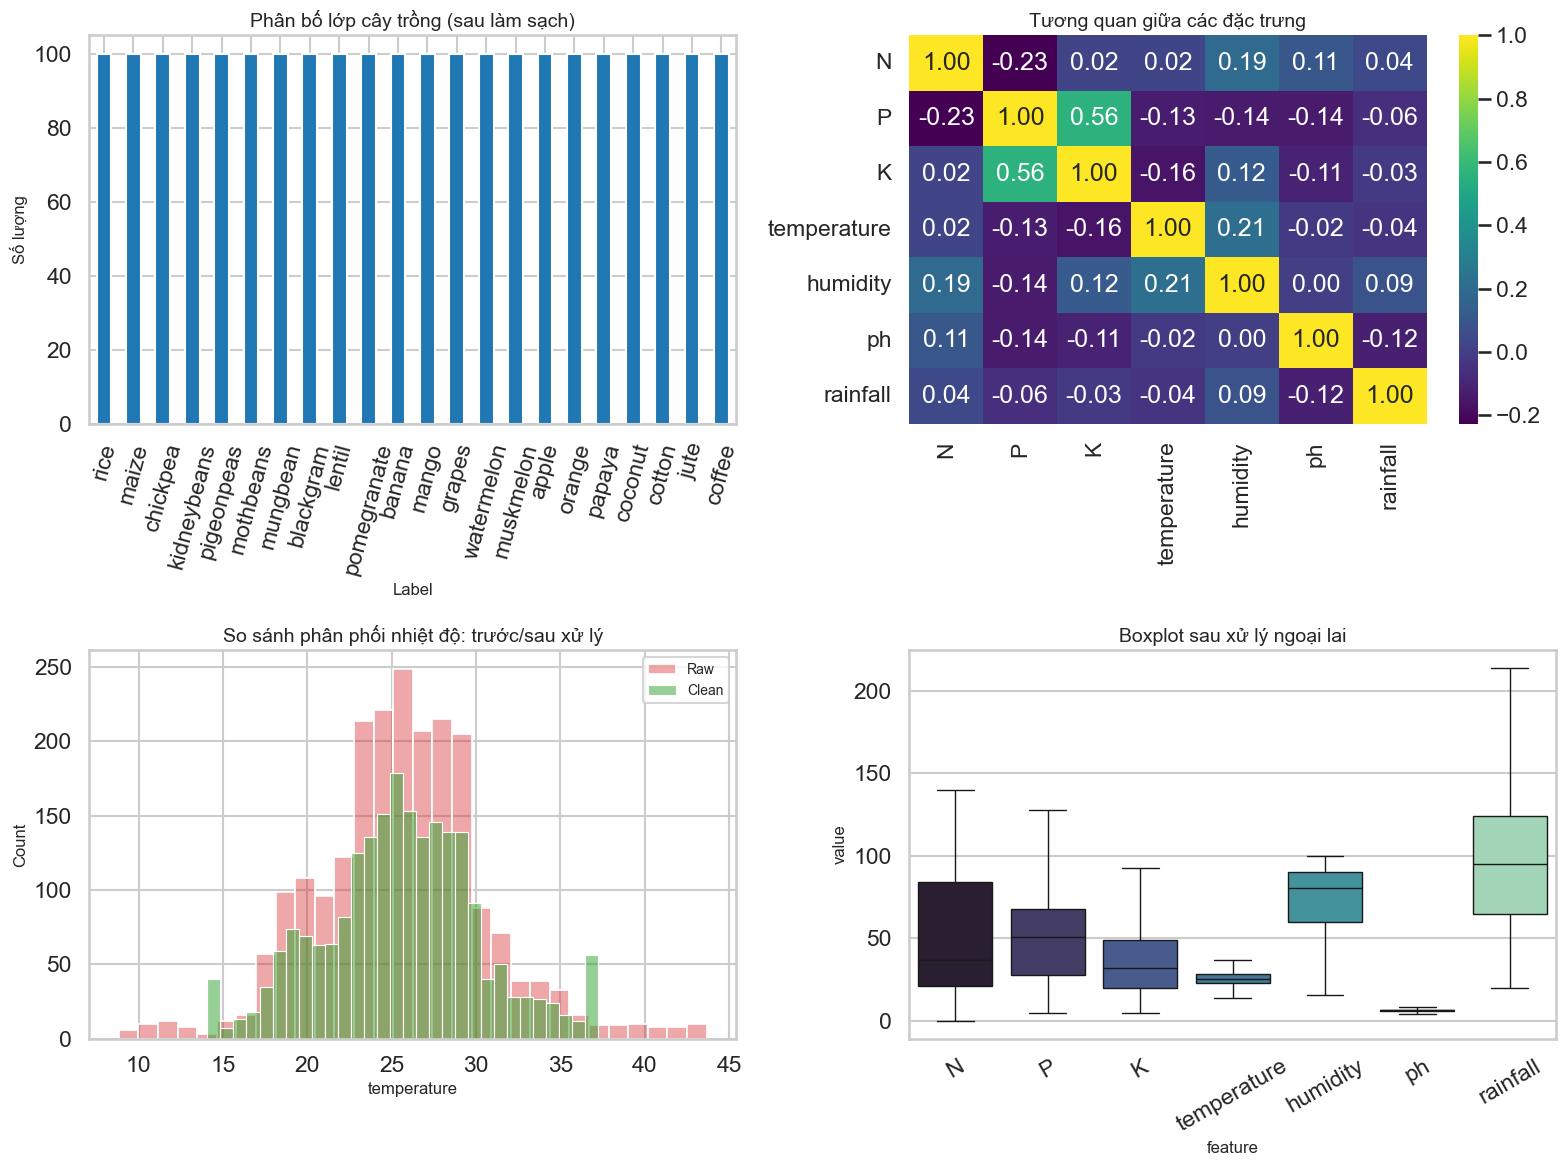

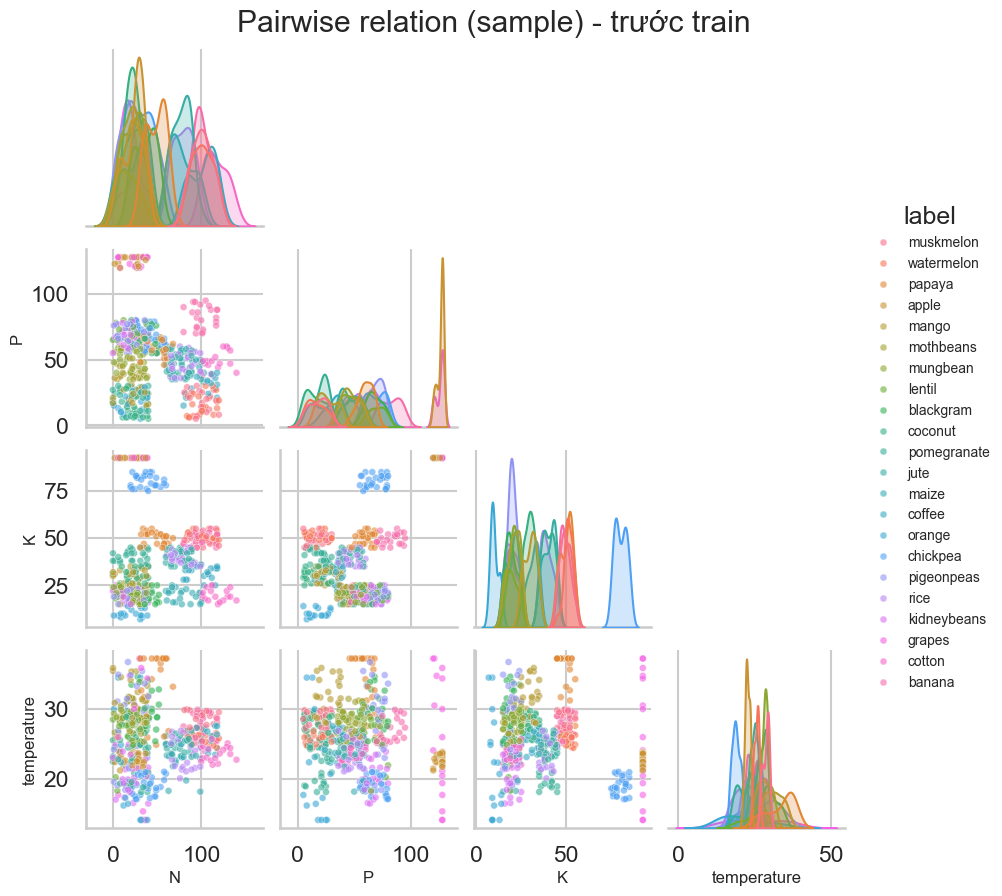

In [5]:
# Visualize data before and after preprocessing
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Class distribution
class_counts = clean_df[TARGET_COLUMN].value_counts().sort_values(ascending=False)
class_counts.plot(kind="bar", ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Phân bố lớp cây trồng (sau làm sạch)")
axes[0, 0].set_xlabel("Label")
axes[0, 0].set_ylabel("Số lượng")
axes[0, 0].tick_params(axis='x', rotation=75)

# Correlation heatmap
corr = clean_df[FEATURE_COLUMNS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", ax=axes[0, 1])
axes[0, 1].set_title("Tương quan giữa các đặc trưng")

# Feature histogram (temperature)
sns.histplot(raw_df["temperature"], bins=30, color="#d62728", alpha=0.4, label="Raw", ax=axes[1, 0])
sns.histplot(clean_df["temperature"], bins=30, color="#2ca02c", alpha=0.5, label="Clean", ax=axes[1, 0])
axes[1, 0].set_title("So sánh phân phối nhiệt độ: trước/sau xử lý")
axes[1, 0].legend()

# Boxplot multi-feature
sample_box = pd.melt(clean_df[FEATURE_COLUMNS], var_name="feature", value_name="value")
sns.boxplot(data=sample_box, x="feature", y="value", palette="mako", ax=axes[1, 1])
axes[1, 1].set_title("Boxplot sau xử lý ngoại lai")
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Pairwise relations (sample to keep runtime reasonable)
sample_for_pairplot = clean_df.sample(min(500, len(clean_df)), random_state=CONFIG.random_seed)
sns.pairplot(
    sample_for_pairplot,
    vars=["N", "P", "K", "temperature"],
    hue=TARGET_COLUMN,
    corner=True,
    plot_kws={"alpha": 0.6, "s": 25},
    height=2.2,
)
plt.suptitle("Pairwise relation (sample) - trước train", y=1.02)
plt.show()

## 5) Cài đặt hàm/lớp lõi

Phần này định nghĩa các hàm chuẩn hóa input, huấn luyện, đánh giá và post-processing để tái sử dụng nhất quán.

In [6]:
def build_models(config: TrainConfig):
    """Return model registry for comparison."""
    return {
        "RandomForest": RandomForestClassifier(**config.rf_params),
        "NaiveBayes": GaussianNB(),
        "KNN": KNeighborsClassifier(**config.knn_params),
        "SVM": SVC(**config.svm_params),
    }


def preprocess_for_training(df: pd.DataFrame):
    """Split dataset and apply MinMax -> Standard scaling for compatibility."""
    X = df[FEATURE_COLUMNS].copy()
    y = df["crop_id"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=CONFIG.test_size,
        random_state=CONFIG.random_seed,
        stratify=y,
    )

    minmax_scaler = MinMaxScaler()
    standard_scaler = StandardScaler()

    X_train_mm = minmax_scaler.fit_transform(X_train)
    X_test_mm = minmax_scaler.transform(X_test)

    X_train_scaled = standard_scaler.fit_transform(X_train_mm)
    X_test_scaled = standard_scaler.transform(X_test_mm)

    bundle = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "X_train_scaled": X_train_scaled,
        "X_test_scaled": X_test_scaled,
        "minmax_scaler": minmax_scaler,
        "standard_scaler": standard_scaler,
    }

    return bundle


def evaluate_model(name, model, X_train_scaled, y_train, X_test_scaled, y_test):
    """Train + evaluate one model, returning metrics and artifacts."""
    start = time.perf_counter()
    model.fit(X_train_scaled, y_train)
    train_time_sec = time.perf_counter() - start

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

    cv = StratifiedKFold(n_splits=CONFIG.cv_folds, shuffle=True, random_state=CONFIG.random_seed)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="accuracy")
    cv_mean = float(np.mean(cv_scores))
    cv_std = float(np.std(cv_scores))

    # Stability-aware score: high cv_mean and low cv_std are preferred.
    stability_score = float(cv_mean - cv_std)
    composite_score = float((0.65 * accuracy) + (0.25 * cv_mean) + (0.10 * stability_score))

    result = {
        "model": name,
        "train_time_sec": train_time_sec,
        "test_accuracy": float(accuracy),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_macro": float(f1_macro),
        "cv_mean": cv_mean,
        "cv_std": cv_std,
        "stability_score": stability_score,
        "composite_score": composite_score,
        "cv_scores": cv_scores.tolist(),
        "classification_report": classification_report(y_test, y_pred, output_dict=True, zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "y_pred": y_pred,
        "fitted_model": model,
    }
    return result

## 6) Chạy pipeline implementation end-to-end

### Quick check
Chạy nhanh trên tập nhỏ để kiểm tra pipeline không lỗi.

### Full run
Sau khi quick check ổn định, chạy toàn bộ dữ liệu để train và thu thập metrics.

In [7]:
# Quick pipeline check on a small sample
quick_df = clean_df.sample(min(200, len(clean_df)), random_state=CONFIG.random_seed)
quick_bundle = preprocess_for_training(quick_df)
quick_model = RandomForestClassifier(n_estimators=50, random_state=CONFIG.random_seed)
quick_model.fit(quick_bundle["X_train_scaled"], quick_bundle["y_train"])
quick_pred = quick_model.predict(quick_bundle["X_test_scaled"])
quick_acc = accuracy_score(quick_bundle["y_test"], quick_pred)
print(f"Quick check accuracy (sample): {quick_acc:.4f}")

Quick check accuracy (sample): 0.9000


In [8]:
# Full train and history collection
bundle = preprocess_for_training(clean_df)
models = build_models(CONFIG)

history = []
artifacts = {}

for model_name, model in models.items():
    print(f"Training {model_name} ...")
    result = evaluate_model(
        model_name,
        model,
        bundle["X_train_scaled"],
        bundle["y_train"],
        bundle["X_test_scaled"],
        bundle["y_test"],
    )
    artifacts[model_name] = result

    history.append({
        "model": result["model"],
        "train_time_sec": result["train_time_sec"],
        "test_accuracy": result["test_accuracy"],
        "precision_macro": result["precision_macro"],
        "recall_macro": result["recall_macro"],
        "f1_macro": result["f1_macro"],
        "cv_mean": result["cv_mean"],
        "cv_std": result["cv_std"],
        "stability_score": result["stability_score"],
        "composite_score": result["composite_score"],
    })

history_df = pd.DataFrame(history).sort_values(by=["composite_score", "test_accuracy"], ascending=False)
display(history_df)

best_model_name = history_df.iloc[0]["model"]
best_result = artifacts[best_model_name]
best_model = best_result["fitted_model"]

print(f"Best model selected: {best_model_name}")
print(f"Accuracy={best_result['test_accuracy']:.4f}, CV mean={best_result['cv_mean']:.4f}, CV std={best_result['cv_std']:.4f}")

Training RandomForest ...
Training NaiveBayes ...
Training KNN ...
Training SVM ...


,model,train_time_sec,test_accuracy,precision_macro,recall_macro,f1_macro,cv_mean,cv_std,stability_score,composite_score
0,RandomForest,0.550997,0.995455,0.995671,0.995455,0.995452,0.994318,0.001797,0.992521,0.994877
1,NaiveBayes,0.001474,0.993182,0.993279,0.993182,0.993178,0.994886,0.001136,0.993750,0.993665
3,SVM,0.150721,0.986364,0.986785,0.986364,0.986355,0.988636,0.006478,0.982158,0.986511
2,KNN,0.001539,0.986364,0.987013,0.986364,0.986351,0.975000,0.008504,0.966496,0.981536


Best model selected: RandomForest
Accuracy=0.9955, CV mean=0.9943, CV std=0.0018


## 7) Đánh giá kết quả bằng metrics và biểu đồ

Mục tiêu là đánh giá đa chiều:
- Accuracy trên tập test.
- Precision/Recall/F1 (macro) cho bài toán đa lớp.
- Độ ổn định thông qua cross-validation mean/std.
- Confusion matrix và classification report cho từng mô hình.
- So sánh trực quan giữa các mô hình.

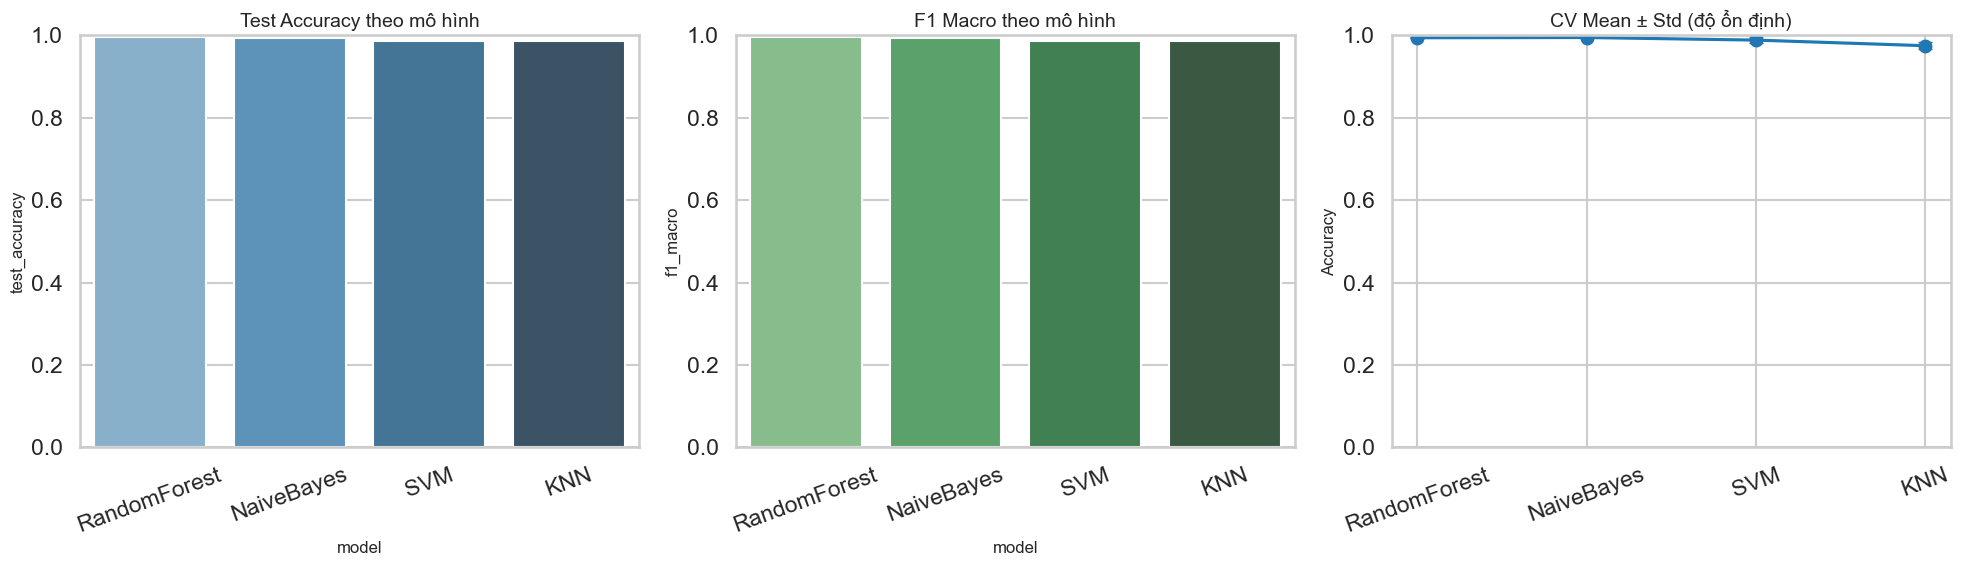

,model,test_accuracy,precision_macro,recall_macro,f1_macro,stability_score
0,RandomForest,0.995455,0.995671,0.995455,0.995452,0.992521
1,NaiveBayes,0.993182,0.993279,0.993182,0.993178,0.993750
3,SVM,0.986364,0.986785,0.986364,0.986355,0.982158
2,KNN,0.986364,0.987013,0.986364,0.986351,0.966496


In [9]:
# Multi-view model comparison
plot_df = history_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(data=plot_df, x="model", y="test_accuracy", palette="Blues_d", ax=axes[0])
axes[0].set_title("Test Accuracy theo mô hình")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=plot_df, x="model", y="f1_macro", palette="Greens_d", ax=axes[1])
axes[1].set_title("F1 Macro theo mô hình")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=20)

axes[2].errorbar(
    x=np.arange(len(plot_df)),
    y=plot_df["cv_mean"],
    yerr=plot_df["cv_std"],
    fmt="o-",
    capsize=5,
    color="#1f77b4",
)
axes[2].set_xticks(np.arange(len(plot_df)))
axes[2].set_xticklabels(plot_df["model"], rotation=20)
axes[2].set_title("CV Mean ± Std (độ ổn định)")
axes[2].set_ylim(0, 1)
axes[2].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

# Radar-style comparison (không chuẩn hóa để giữ đúng ý nghĩa)
radar_cols = ["test_accuracy", "precision_macro", "recall_macro", "f1_macro", "stability_score"]
radar_df = plot_df[["model"] + radar_cols].copy()
display(radar_df)

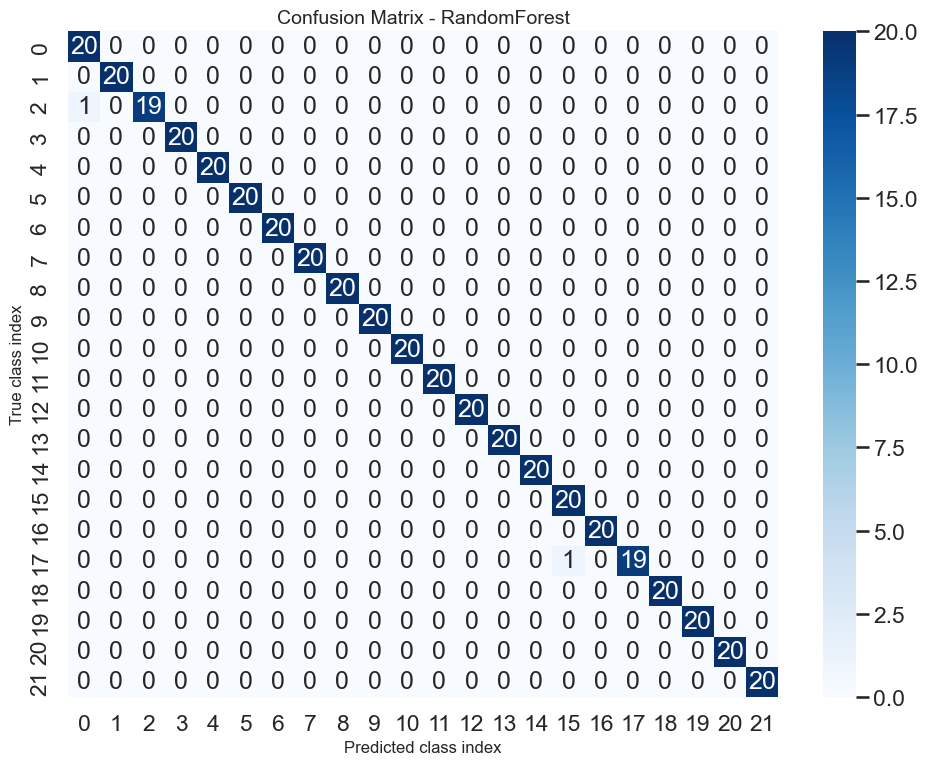

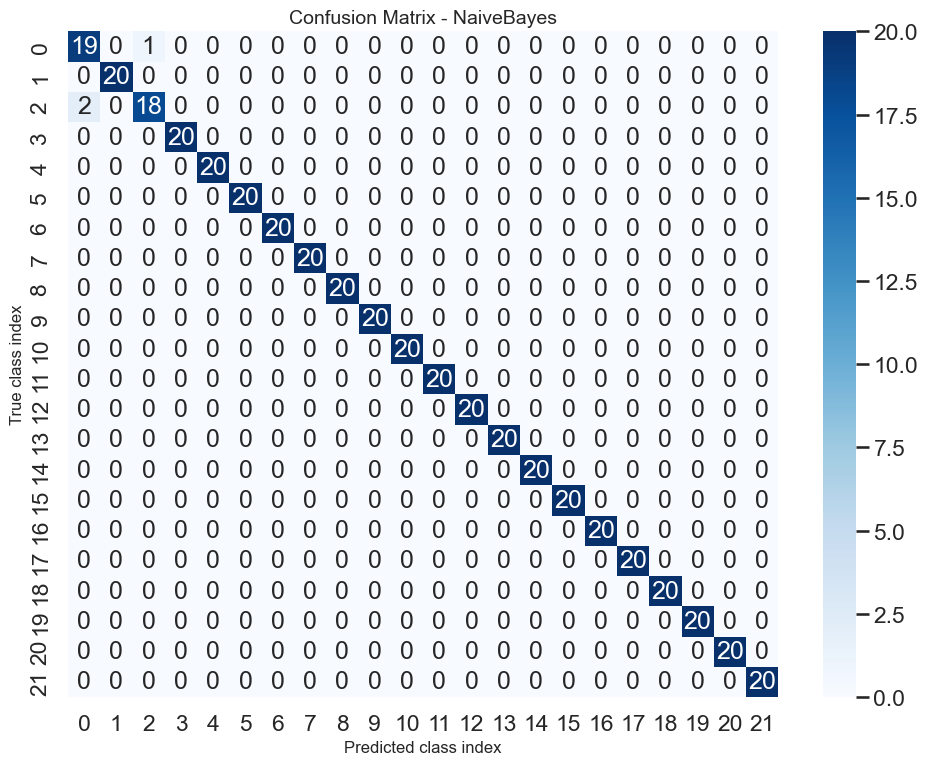

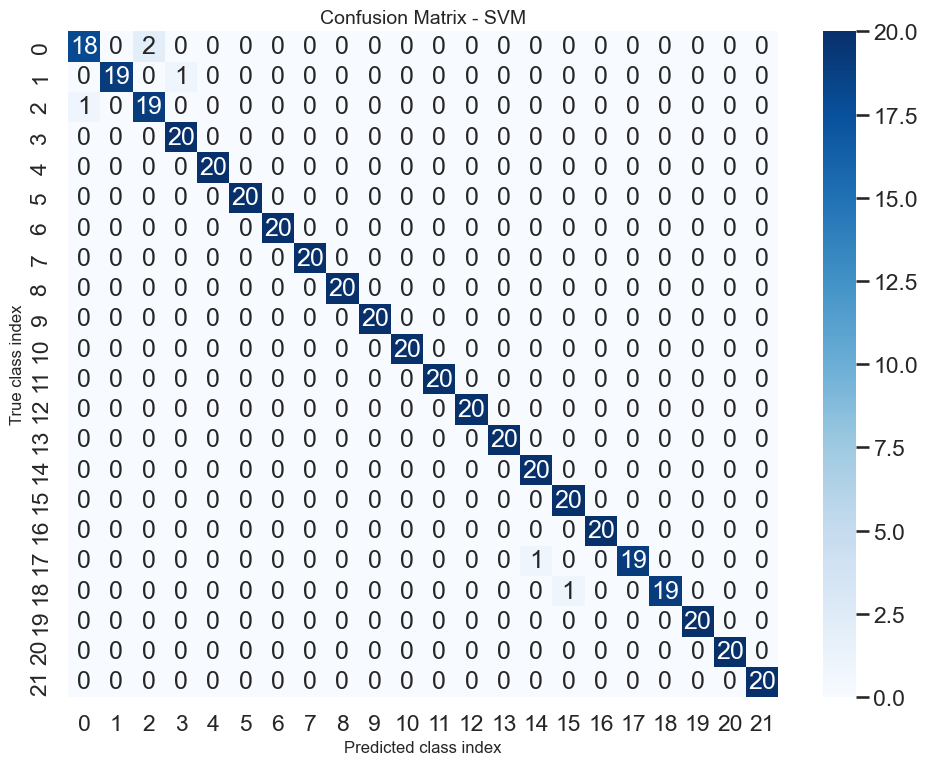

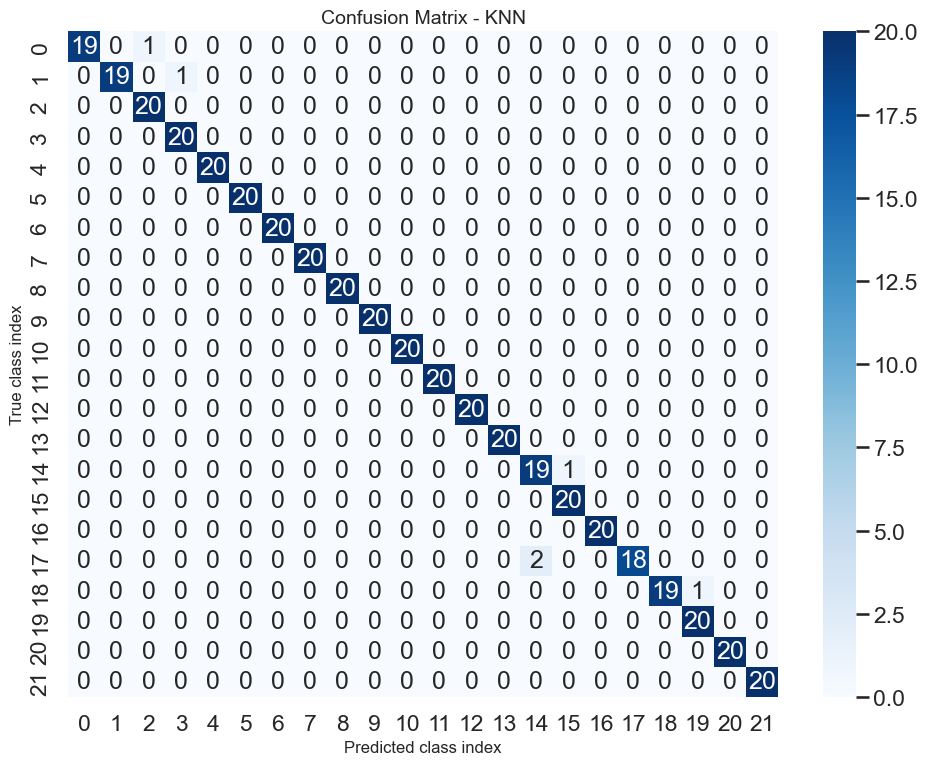

In [10]:
# Confusion matrix for each model
labels_sorted = sorted(clean_df["crop_id"].unique())

for model_name in history_df["model"].tolist():
    cm = artifacts[model_name]["confusion_matrix"]
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap="Blues", annot=True, fmt="g", cbar=True)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted class index")
    plt.ylabel("True class index")
    plt.tight_layout()
    plt.show()

In [11]:
# Bảng tổng hợp so sánh 4 chỉ số cuối cùng của các mô hình
comparison_cols = ["model", "test_accuracy", "precision_macro", "recall_macro", "f1_macro"]
comparison_df = plot_df[comparison_cols].copy()
comparison_df.columns = ["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
display(comparison_df)


,Model,Accuracy,Precision,Recall,F1-Score
0,RandomForest,0.995455,0.995671,0.995455,0.995452
1,NaiveBayes,0.993182,0.993279,0.993182,0.993178
3,SVM,0.986364,0.986785,0.986364,0.986355
2,KNN,0.986364,0.987013,0.986364,0.986351


In [12]:
# Classification reports
for model_name in history_df["model"].tolist():
    print("=" * 100)
    print(f"Classification report - {model_name}")
    report_df = pd.DataFrame(artifacts[model_name]["classification_report"]).T
    display(report_df.round(4))

Classification report - RandomForest


,precision,recall,f1-score,support
1,0.9524,1.0000,0.9756,20.0000
2,1.0000,1.0000,1.0000,20.0000
3,1.0000,0.9500,0.9744,20.0000
4,1.0000,1.0000,1.0000,20.0000
5,1.0000,1.0000,1.0000,20.0000
6,1.0000,1.0000,1.0000,20.0000
7,1.0000,1.0000,1.0000,20.0000
8,1.0000,1.0000,1.0000,20.0000
9,1.0000,1.0000,1.0000,20.0000
10,1.0000,1.0000,1.0000,20.0000


Classification report - NaiveBayes


,precision,recall,f1-score,support
1,0.9048,0.9500,0.9268,20.0000
2,1.0000,1.0000,1.0000,20.0000
3,0.9474,0.9000,0.9231,20.0000
4,1.0000,1.0000,1.0000,20.0000
5,1.0000,1.0000,1.0000,20.0000
6,1.0000,1.0000,1.0000,20.0000
7,1.0000,1.0000,1.0000,20.0000
8,1.0000,1.0000,1.0000,20.0000
9,1.0000,1.0000,1.0000,20.0000
10,1.0000,1.0000,1.0000,20.0000


Classification report - SVM


,precision,recall,f1-score,support
1,0.9474,0.9000,0.9231,20.0000
2,1.0000,0.9500,0.9744,20.0000
3,0.9048,0.9500,0.9268,20.0000
4,0.9524,1.0000,0.9756,20.0000
5,1.0000,1.0000,1.0000,20.0000
6,1.0000,1.0000,1.0000,20.0000
7,1.0000,1.0000,1.0000,20.0000
8,1.0000,1.0000,1.0000,20.0000
9,1.0000,1.0000,1.0000,20.0000
10,1.0000,1.0000,1.0000,20.0000


Classification report - KNN


,precision,recall,f1-score,support
1,1.0000,0.9500,0.9744,20.0000
2,1.0000,0.9500,0.9744,20.0000
3,0.9524,1.0000,0.9756,20.0000
4,0.9524,1.0000,0.9756,20.0000
5,1.0000,1.0000,1.0000,20.0000
6,1.0000,1.0000,1.0000,20.0000
7,1.0000,1.0000,1.0000,20.0000
8,1.0000,1.0000,1.0000,20.0000
9,1.0000,1.0000,1.0000,20.0000
10,1.0000,1.0000,1.0000,20.0000


## 8) Lưu mô hình, output và log

Ở bước triển khai, notebook sẽ:
- Tạo version mới trong thư mục `models/versions/<version>`.
- Lưu `model.pkl`, `standscaler.pkl`, `minmaxscaler.pkl`.
- Lưu `training_metrics.json` và `history.csv`.
- Cập nhật `models/latest_version.txt` để server có thể đọc phiên bản mới.
- Chạy smoke test bằng artifact vừa lưu.

In [15]:
import shutil

run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_version = f"v{run_timestamp}"

model_root = Path(CONFIG.model_root)
version_dir = model_root / "versions" / model_version
output_dir = Path(CONFIG.output_root) / run_timestamp
version_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

# Save model and scalers (production-compatible names)
with open(version_dir / "model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open(version_dir / "standscaler.pkl", "wb") as f:
    pickle.dump(bundle["standard_scaler"], f)

with open(version_dir / "minmaxscaler.pkl", "wb") as f:
    pickle.dump(bundle["minmax_scaler"], f)

# Save training logs
history_df.to_csv(output_dir / "history.csv", index=False)
outlier_stats.to_csv(output_dir / "outlier_stats.csv", index=False)

metrics_payload = {
    "training_timestamp": run_timestamp,
    "selected_model": best_model_name,
    "model_version": model_version,
    "dataset_path": str(data_path),
    "feature_columns": FEATURE_COLUMNS,
    "target_mapping": CROP_TO_ID,
    "clean_summary": clean_summary,
    "model_history": history,
    "best_model_metrics": {
        "test_accuracy": best_result["test_accuracy"],
        "precision_macro": best_result["precision_macro"],
        "recall_macro": best_result["recall_macro"],
        "f1_macro": best_result["f1_macro"],
        "cv_mean": best_result["cv_mean"],
        "cv_std": best_result["cv_std"],
        "stability_score": best_result["stability_score"],
        "composite_score": best_result["composite_score"],
    },
    "split": {
        "train_size": int(len(bundle["X_train"])),
        "test_size": int(len(bundle["X_test"])),
    },
}

with open(version_dir / "training_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2, ensure_ascii=False)

with open(model_root / "latest_version.txt", "w", encoding="utf-8") as f:
    f.write(model_version)

# Optional convenience copy to legacy paths for rollback compatibility
for file_name in ["model.pkl", "standscaler.pkl", "minmaxscaler.pkl"]:
    shutil.copyfile(version_dir / file_name, model_root / file_name)

print("Saved artifacts:")
print(f"- Version directory: {version_dir}")
print(f"- Output logs: {output_dir}")
print(f"- latest_version.txt -> {model_version}")

# Smoke test with saved artifacts
with open(version_dir / "model.pkl", "rb") as f:
    smoke_model = pickle.load(f)
with open(version_dir / "standscaler.pkl", "rb") as f:
    smoke_sc = pickle.load(f)
with open(version_dir / "minmaxscaler.pkl", "rb") as f:
    smoke_mm = pickle.load(f)

sample_row = clean_df[FEATURE_COLUMNS].iloc[[0]].values
sample_mm = smoke_mm.transform(sample_row)
sample_scaled = smoke_sc.transform(sample_mm)
smoke_pred_id = int(smoke_model.predict(sample_scaled)[0])

print(f"Smoke prediction crop_id: {smoke_pred_id}")
print(f"Smoke prediction crop_name: {ID_TO_CROP.get(smoke_pred_id, 'unknown')}")

Saved artifacts:
- Version directory: models\versions\v20260427_014043
- Output logs: training_outputs\20260427_014043
- latest_version.txt -> v20260427_014043
Smoke prediction crop_id: 1
Smoke prediction crop_name: rice


## 9) Gợi ý triển khai vào predict server

Sau khi train xong:
1. Server Flask đã hỗ trợ đọc model theo phiên bản (`ML_MODEL_VERSION` hoặc `latest_version.txt`).
2. Nếu muốn dùng bản mới ngay, giữ nguyên `models/latest_version.txt` vừa được cập nhật.
3. Khởi động lại ML server để nạp artifact mới.
4. Test endpoint `/model-info` và `/predict` để xác nhận model version đang phục vụ.

Kết quả notebook này cho phép so sánh khách quan giữa Naive Bayes, Random Forest, KNN, SVM và chọn mô hình vừa mạnh vừa ổn định cho production.